# Explorative Data Analysis

# _____________________________________________

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from scipy import stats

## Load Data

In [18]:
data = pd.read_parquet("data/entsoe_price_and_loadfc.parquet")
weather_fc = pd.read_parquet("data/NOAA GFS/weather_forecast.parquet")
df = data.join(weather_fc, how="left")

# only keep data from 2023-01-01 to 2025-12-31
df = df["2023":"2025"]
# only train data
df_train = df["2023":"2024"]

## Data Quality Check

In [19]:
# Ensure expected period
expected_index = pd.date_range(start="2023-01-01 00:00:00+01:00", end="2025-12-31 23:00:00+01:00", freq="h")
missing_timestamps = expected_index.difference(df.index)
extra_timestamps = df.index.difference(expected_index)

# Data quality checks
quality_checks = {
    "start": str(df.index.min()),
    "end": str(df.index.max()),
    "rows": len(df),
    "columns": len(df.columns),
    "frequency": str(pd.infer_freq(df.index)),
    "monotonic increasing": bool(df.index.is_monotonic_increasing),
    "duplicate index": bool(df.index.duplicated().any()),
    "missing rows/hours": int(len(missing_timestamps)),
    "extra rows/hours": int(len(extra_timestamps)),
    "timezone": str(df.index.tz),
    "missing values":df.isna().sum().sum(),
}

quality_df = pd.DataFrame.from_dict(quality_checks, orient="index", columns=["value"])
quality_df

,value
start,2023-01-01 00:00:00+01:00
end,2025-12-31 23:00:00+01:00
rows,26304
columns,8
frequency,h
monotonic increasing,True
duplicate index,False
missing rows/hours,0
extra rows/hours,0
timezone,Europe/Berlin


# Insights target variable `da_price` 

In [20]:
yearly = df.groupby(df.index.year)["da_price"].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])
total = df["da_price"].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).to_frame().T
total.index = ["all data"]

display("da_price summary statistics:")
display(pd.concat([yearly, total]).round(2))

'da_price summary statistics:'

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
2023,8760.0,95.18,47.58,-500.00,-5.24,1.07,75.88,98.02,122.12,166.25,207.98,524.27
2024,8784.0,78.51,52.73,-135.45,-19.95,-0.01,55.56,79.59,101.34,143.25,224.86,936.28
2025,8760.0,89.32,52.10,-250.32,-18.89,-0.11,71.09,92.43,114.14,162.35,242.84,583.40
all data,26304.0,87.66,51.32,-500.00,-14.99,-0.01,65.06,90.06,112.97,159.90,222.07,936.28


da_price seems to have some strong outliers.

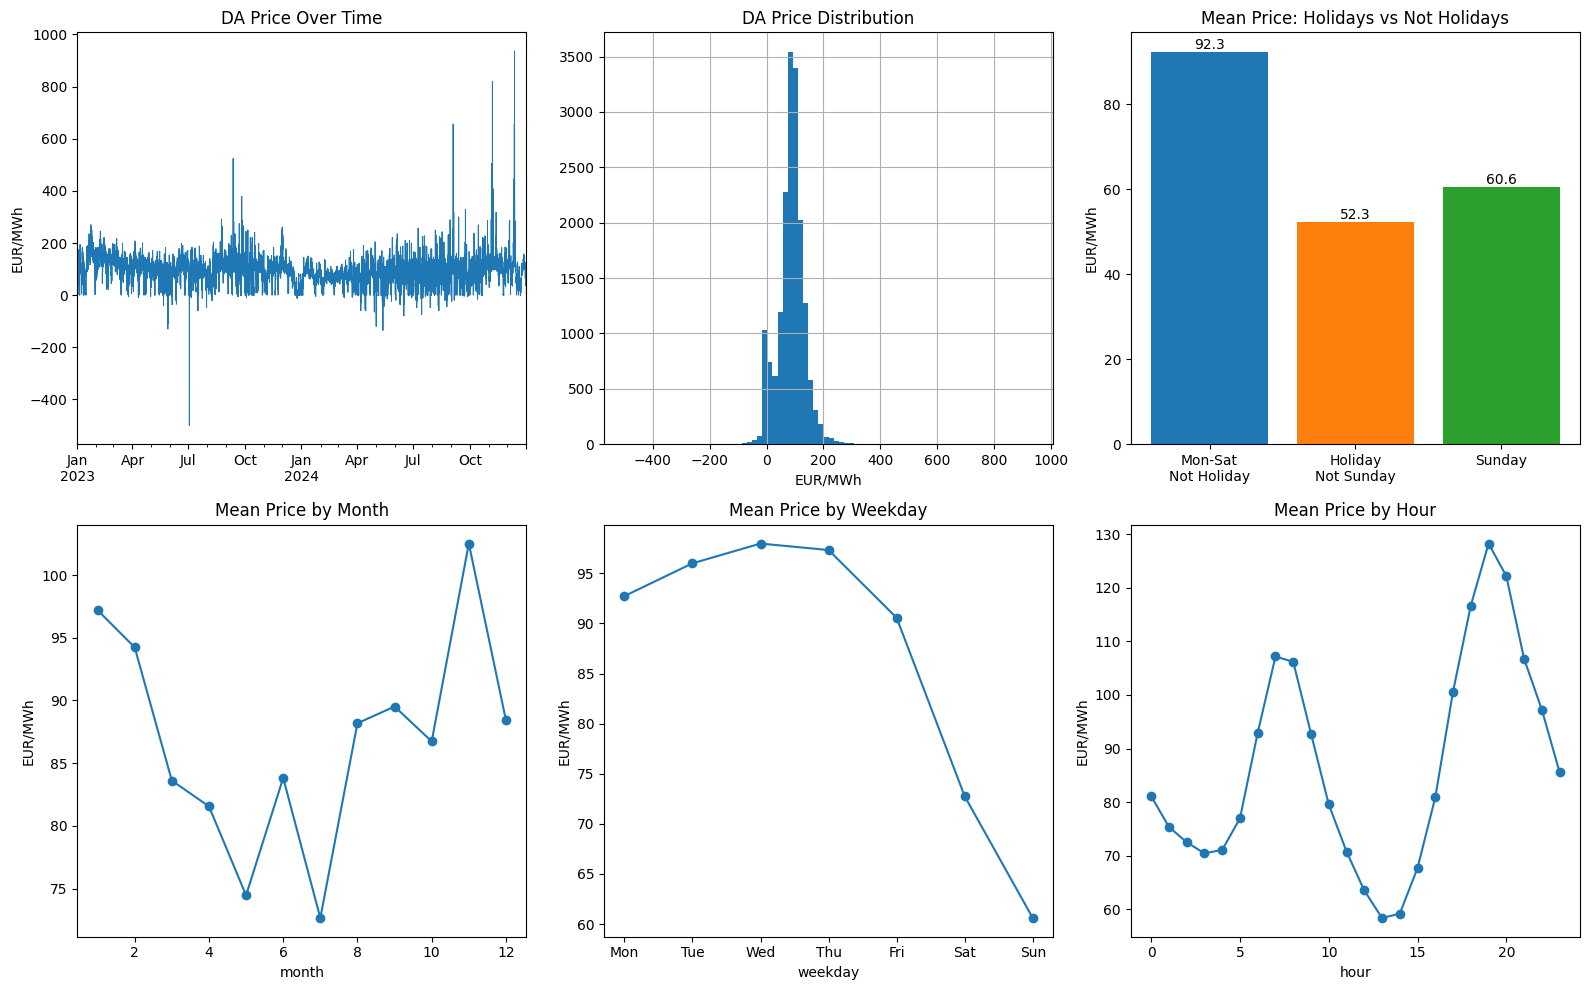

In [27]:
import holidays

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

df_train["da_price"].plot(ax=axes[0, 0], title="DA Price Over Time", linewidth=0.7)
axes[0, 0].set_ylabel("EUR/MWh")

df_train["da_price"].hist(ax=axes[0, 1], bins=80)
axes[0, 1].set_title("DA Price Distribution")
axes[0, 1].set_xlabel("EUR/MWh")

df_train.assign(month=df_train.index.month).groupby("month")["da_price"].mean().plot(ax=axes[1, 0], marker="o", title="Mean Price by Month")
axes[1, 0].set_ylabel("EUR/MWh")

df_train.assign(weekday=df_train.index.dayofweek).groupby("weekday")["da_price"].mean().plot(ax=axes[1, 1], marker="o", title="Mean Price by Weekday")
axes[1, 1].set_ylabel("EUR/MWh")
axes[1, 1].set_xticks(range(7))
axes[1, 1].set_xticklabels(["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"])

df_train.assign(hour=df_train.index.hour).groupby("hour")["da_price"].mean().plot(ax=axes[1, 2], marker="o", title="Mean Price by Hour")
axes[1, 2].set_ylabel("EUR/MWh")

# mean price on regular days vs public holidays
# (same holiday definition as the holiday_not_sunday feature in modelling.ipynb)
ger_holidays = list(holidays.Germany(years=df_train.index.year.unique()))
ger_holidays = pd.to_datetime(ger_holidays).tz_localize(df_train.index.tz)
is_holiday = df_train.index.normalize().isin(ger_holidays) & (df_train.index.dayofweek != 6)

is_sunday = df_train.index.dayofweek == 6
is_workday = (df_train.index.dayofweek <= 5) & ~is_holiday   # Mon-Sat, non-holiday reference

means = [
    df_train.loc[is_workday, "da_price"].mean(),
    df_train.loc[is_holiday, "da_price"].mean(),
    df_train.loc[is_sunday, "da_price"].mean(),
]
bars = axes[0, 2].bar(
    ["Mon-Sat\nNot Holiday", "Holiday\nNot Sunday", "Sunday"],
    means, color=["tab:blue", "tab:orange", "tab:green"],
)
axes[0, 2].bar_label(bars, fmt="%.1f")
axes[0, 2].set_title("Mean Price: Holidays vs Not Holidays")
axes[0, 2].set_ylabel("EUR/MWh")

plt.tight_layout()

1. Figure: Some strong outliers that could have a too big impact on the model. Maybe a transformation needed.

2. Figure: Day ahead price is almost normally distributed.

3. Figure: Big difference in mean price of holidays and not holidays.

4. Figure: Yearly seasonality visible. Probably month information important for model.

5. Figure: Strong daily pattern. "Hour of day" variable useful for the model.

6. Figure: Strong weekly pattern. "Day of the week" variable useful for the model.

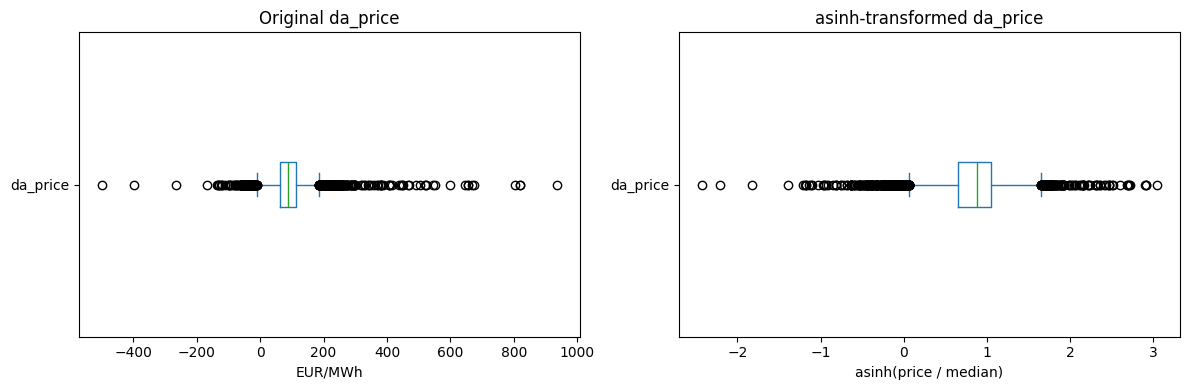

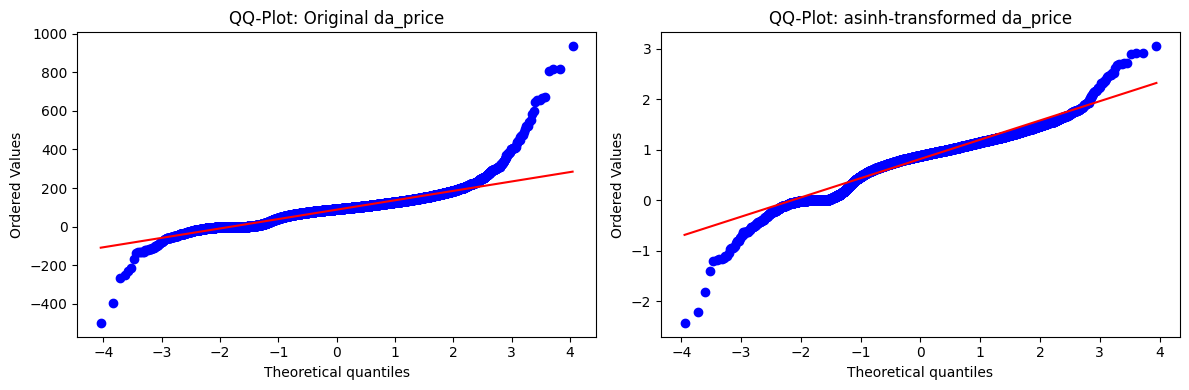

In [6]:
# asinh transformation to reduce outlier impact while preserving zero and negative values

c = np.median(np.abs(df_train["da_price"]))
transformed = np.arcsinh(df_train["da_price"] / c)

# BOXPLOT
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df_train["da_price"].plot.box(ax=axes[0], vert=False)
axes[0].set_title("Original da_price")
axes[0].set_xlabel("EUR/MWh")

transformed.plot.box(ax=axes[1], vert=False)
axes[1].set_title("asinh-transformed da_price")
axes[1].set_xlabel("asinh(price / median)")

plt.tight_layout()


# QQ-PLOT
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

stats.probplot(df["da_price"], plot=axes[0])
axes[0].set_title("QQ-Plot: Original da_price")

stats.probplot(transformed, plot=axes[1])
axes[1].set_title("QQ-Plot: asinh-transformed da_price")


plt.tight_layout()

The QQ-Plot has a very heavy tail on the upper end. Prices go up to over 800 while the most data is between 0 and 200. This is almost fixed by the transformation. It's also shown in the boxplot, where the relative distances from the outliers to the IQR are strongly reduced for the higher prices.

fitted lambda: 0.9747


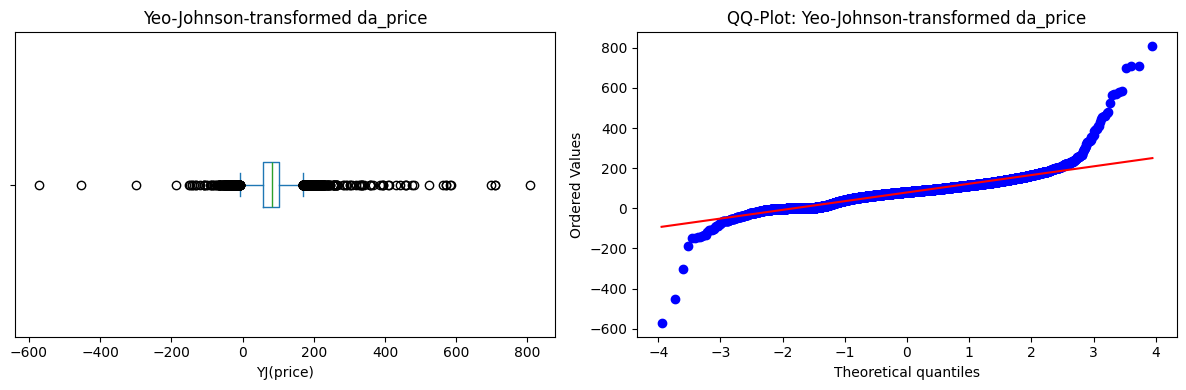

In [ ]:
# Alternative 1: Yeo-Johnson transformation
from sklearn.preprocessing import PowerTransformer

pt = PowerTransformer(method="yeo-johnson", standardize=False)
yj = pt.fit_transform(df_train[["da_price"]].to_numpy(dtype=np.float64)).ravel()
print(f"fitted lambda: {pt.lambdas_[0]:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

pd.Series(yj).plot.box(ax=axes[0], vert=False)
axes[0].set_title("Yeo-Johnson-transformed da_price")
axes[0].set_xlabel("YJ(price)")

stats.probplot(yj, plot=axes[1])
axes[1].set_title("QQ-Plot: Yeo-Johnson-transformed da_price")

plt.tight_layout()

No big difference to not-transformed price. Way worse than asinh transformation.

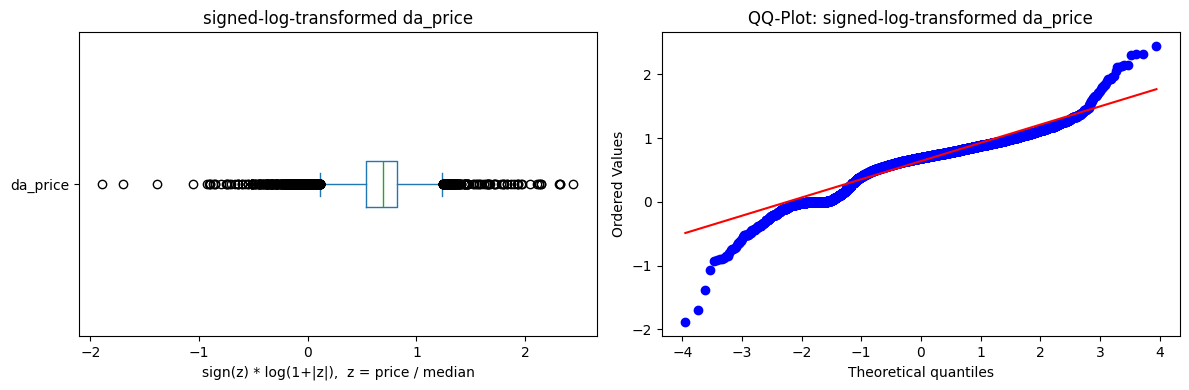

In [ ]:
# Alternative 2: signed log transformation [sign(z) * log(1 + |z|)]

c_sl = np.median(np.abs(df_train["da_price"]))
z = df_train["da_price"] / c_sl
signedlog = np.sign(z) * np.log1p(np.abs(z))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

signedlog.plot.box(ax=axes[0], vert=False)
axes[0].set_title("signed-log-transformed da_price")
axes[0].set_xlabel("sign(z) * log(1+|z|),  z = price / median")

stats.probplot(signedlog, plot=axes[1])
axes[1].set_title("QQ-Plot: signed-log-transformed da_price")

plt.tight_layout()

No difference notable to asinh transformation.

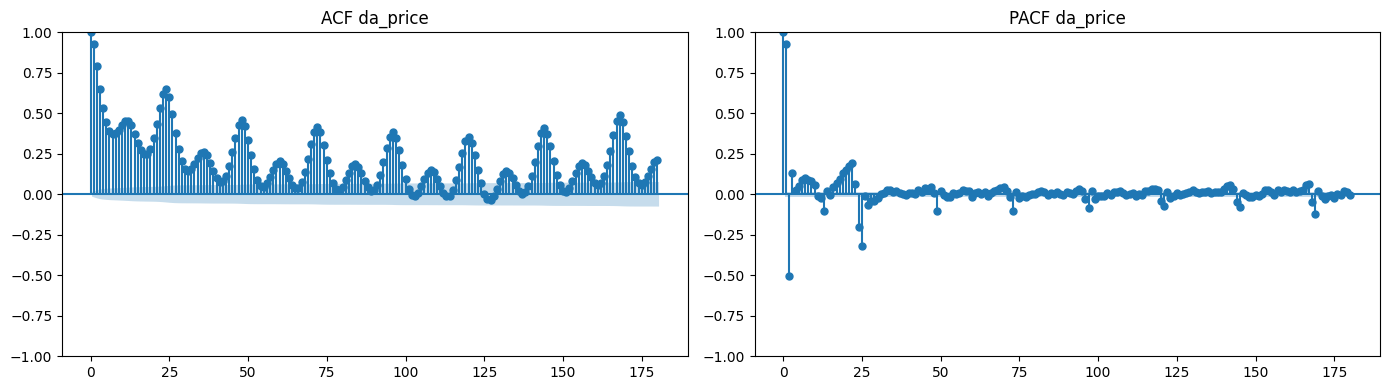

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(df_train["da_price"], lags=180, ax=axes[0], title="ACF da_price")
plot_pacf(df_train["da_price"], lags=180, ax=axes[1], title="PACF da_price", method="ywm")
plt.tight_layout()

The ACF shows repeating peaks every 24h, pointing to daily seasonality. The PACF confirms this: lag 24 stays significant even after controlling for shorter lags, so it reflects a real, independent daily effect rather than just carry-over from AR(1)/AR(2) short-term correlation. A weekly peak at lag 168 shows up in the ACF and PACF, but pretty weak. Suggesting there is an independent weekly effect, but not that big. Lag 24h is therefore well justified as a feature; lag 168h and 48h are worth testing as candidates, but their independent value should be checked (e.g. via feature importance) rather than assumed from the ACF alone.

# Insights `load_fc` and it's relation to `da_price`

In [19]:
yearly = df.groupby(df.index.year)["load_fc"].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])
total = df["load_fc"].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).to_frame().T
total.index = ["all data"]

display("load_fc summary statistics:")
pd.concat([yearly, total]).round(2)

'load_fc summary statistics:'

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
2023,8760.0,212173.25,37405.30,123572.22,138797.07,153665.91,181848.44,212017.02,241254.64,273246.78,284671.02,296167.30
2024,8784.0,212617.64,35583.92,130049.36,145061.39,158322.04,182888.92,210515.30,243942.14,267377.14,278363.91,292979.69
2025,8760.0,216497.47,34921.22,143584.45,151404.64,162932.97,187767.38,215323.34,244651.96,273790.97,284181.57,293668.08
all data,26304.0,213761.74,36036.09,123572.22,144082.60,158058.58,184311.12,212580.84,243347.04,271644.37,283278.22,296167.30


/var/folders/tx/x04j09h149n2njzlqqys6rbh0000gn/T/ipykernel_31140/4042067031.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_by_bin = df_train.groupby(binned)["da_price"].mean()


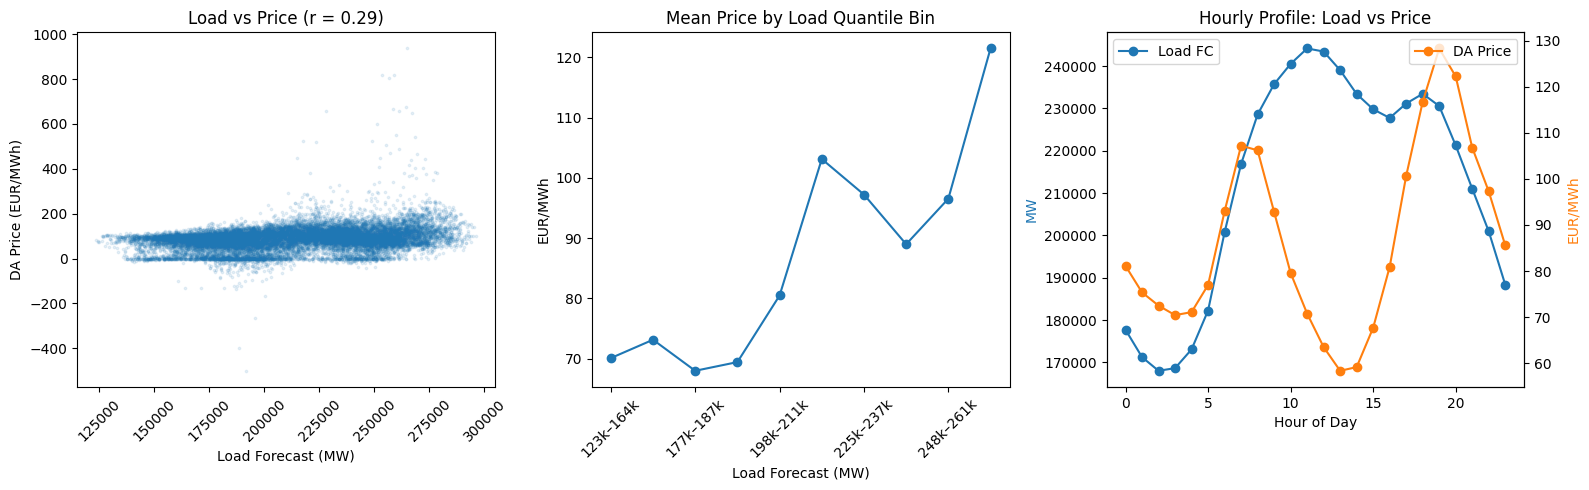

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Scatterplot load_fc vs da_price
axes[0].scatter(df_train["load_fc"], df_train["da_price"], alpha=0.1, s=3)
axes[0].set_xlabel("Load Forecast (MW)")
axes[0].set_ylabel("DA Price (EUR/MWh)")
axes[0].set_title(f"Load vs Price (r = {df_train['load_fc'].corr(df_train['da_price']):.2f})")
axes[0].tick_params(axis="x", rotation=45)

# 2. Quantile-Bin-Plot (non-linear relationship)
binned = pd.qcut(df_train["load_fc"], q=10, duplicates="drop")
mean_by_bin = df_train.groupby(binned)["da_price"].mean()
# x-axis labels: quantile boundaries (min/max of bins)
bin_labels = [f"{int(iv.left/1000)}k–{int(iv.right/1000)}k" for iv in mean_by_bin.index.categories]
mean_by_bin.index = bin_labels
mean_by_bin.plot(ax=axes[1], marker="o", title="Mean Price by Load Quantile Bin")
axes[1].set_ylabel("EUR/MWh")
axes[1].set_xlabel("Load Forecast (MW)")
axes[1].tick_params(axis="x", rotation=45)

# 3. Hourly profile: load_fc vs da_price (dual axis)
hourly_load = df_train.groupby(df_train.index.hour)["load_fc"].mean()
hourly_price = df_train.groupby(df_train.index.hour)["da_price"].mean()
ax_left = axes[2]
ax_right = ax_left.twinx()
ax_left.plot(hourly_load.index, hourly_load.values, marker="o", color="tab:blue", label="Load FC")
ax_right.plot(hourly_price.index, hourly_price.values, marker="o", color="tab:orange", label="DA Price")
ax_left.set_xlabel("Hour of Day")
ax_left.set_ylabel("MW", color="tab:blue")
ax_right.set_ylabel("EUR/MWh", color="tab:orange")
ax_left.set_title("Hourly Profile: Load vs Price")
ax_left.legend(loc="upper left")
ax_right.legend(loc="upper right")

plt.tight_layout()

There is a positive correlation between load forecast and day-ahead price. However, as shown in the second figure, this relationship is non-linear. Additionally, the third plot reveals that the two curves diverge during midday hours, indicating that other variables, such as temporal features or energy generation, are needed to fully explain price behavior.

# Insights Weather Features and their relation to `da_price`

In [29]:
weather_cols = ["ssrd", "tcc", "t2m", "rh2m", "U100", "sp"]
weather_summary = df[weather_cols].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T.round(2)
weather_summary

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
ssrd,26304.0,136.50,193.82,0.00,0.00,0.00,0.00,20.85,232.26,560.26,703.62,869.27
tcc,26304.0,66.64,26.93,0.00,3.56,13.56,48.11,73.34,89.71,98.77,99.92,100.00
t2m,26304.0,283.55,7.10,266.10,269.88,272.67,278.24,283.02,288.60,295.84,300.28,306.98
rh2m,26304.0,77.14,13.20,27.60,40.53,49.97,69.62,80.72,87.29,92.55,95.22,97.98
U100,26304.0,7.13,2.91,1.17,2.45,3.24,4.96,6.68,8.77,12.76,15.61,20.55
sp,26304.0,100060.08,947.29,96174.27,97502.18,98362.30,99499.96,100108.86,100697.47,101538.41,102113.76,102672.14


### Correlation with da_price

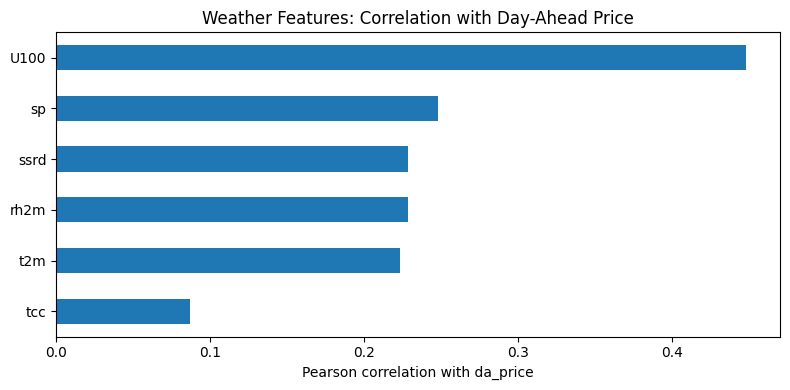

In [38]:
corr_with_price = df_train[weather_cols].corrwith(transformed).abs().sort_values()

fig, ax = plt.subplots(figsize=(8, 4))
corr_with_price.plot.barh(ax=ax)
ax.set_xlabel("Pearson correlation with da_price")
ax.set_title("Weather Features: Correlation with Day-Ahead Price")
ax.axvline(0, color="black", linewidth=0.5)
plt.tight_layout()

### Multicolliniarity check (Correlationmatrix)

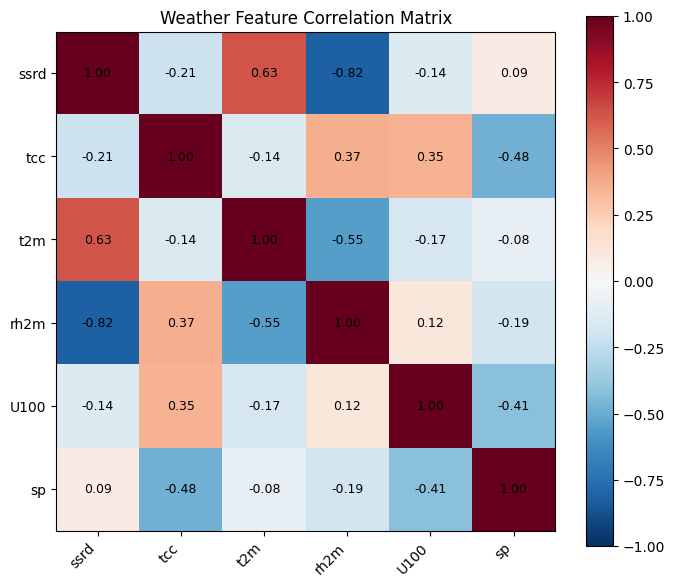

In [37]:
fig, ax = plt.subplots(figsize=(7, 6))
corr_matrix = df[weather_cols].corr()
im = ax.imshow(corr_matrix, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(weather_cols)))
ax.set_yticks(range(len(weather_cols)))
ax.set_xticklabels(weather_cols, rotation=45, ha="right")
ax.set_yticklabels(weather_cols)

# Annotate with values
for i in range(len(weather_cols)):
    for j in range(len(weather_cols)):
        ax.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}", ha="center", va="center", fontsize=9)

plt.colorbar(im, ax=ax)
ax.set_title("Weather Feature Correlation Matrix")
plt.tight_layout()

High correlation between *ssrd*, *t2m* and *rh2m*. Probably because all have mainly impact on solar generation. Same for *U100* and *sp* on wind generation.

### Scatterplot of top 3 weather features with highest correlation with price

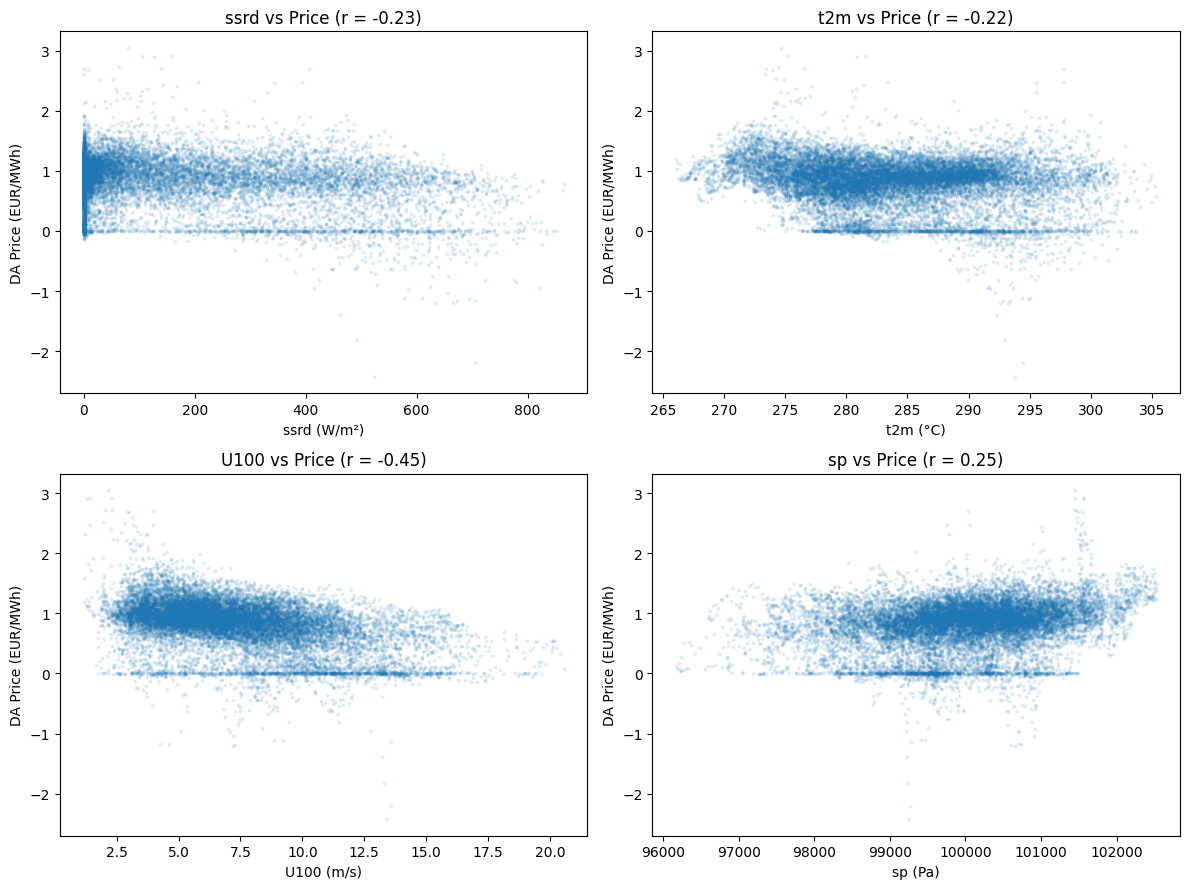

In [36]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
units = {"ssrd": "W/m²", "t2m": "°C", "U100": "m/s", "sp": "Pa"}

for ax, col in zip(axes.flat, ["ssrd", "t2m", "U100", "sp"]):
    ax.scatter(df_train[col], transformed, alpha=0.1, s=3)
    ax.set_xlabel(f"{col} ({units.get(col, '')})")
    ax.set_ylabel("DA Price (EUR/MWh)")
    r = df_train[col].corr(transformed)
    ax.set_title(f"{col} vs Price (r = {r:.2f})")

plt.tight_layout()

*ssrd*, *U100* and *t2m* seem to be the most interesting features with the highest correlations with price. Though, *ssrd* and *t2m* both mainly as indicators for solar have a high correlation between each other. Taking one of them could work as proxy for solar generation as well as *U100* as proxy for wind generation.